In [ ]:
### Imports

# 1. General Library Imports
import os
import re
import ast

# 2. 3rd Party Packages
from dotenv import load_dotenv
from google import genai
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import trim_mean
import seaborn as sns
from sqlalchemy import create_engine, text

# 3. Personal Functions
from helper_functions import run_query

# Client's requirements. 

Investor Zachary Brooks:
Looking to invest in real estate with specific requirements:
Historical houses in the best neighborhoods, and with the best ROI, based on the best time to buy a renovated or non renovated house.


### Main Objective: Maximize ROI with following specific requirements:

1. Historical houses
2. Renovated or no?
3. Best neighborhoods
4. Best timing to buy and sell a house within a year

In [ ]:
### DB Connection

load_dotenv()


db_type = os.getenv("DB_TYPE")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

connection_str = f"{db_type}://{user}:{password}@{host}:{port}/{database}"
engine = create_engine(connection_str)

# ## To test the connection when having problems
# try:
#     with engine.connect() as connection:
#         result = connection.execute(text("SELECT version();"))
#         print("Successfully connected!")
#         print(f"Database version: {result.fetchone()[0]}")
# except Exception as e:
#     print(f"Error connecting to database: {e}")

In [ ]:
# def run_query(query_string):
#     """Executes a SQL query and returns a pandas DataFrame."""
#     return pd.read_sql(sql=text(query_string), con=engine)

In [27]:
### Exploring the house_details table


house_details = run_query(
    """
select * FROM eda.king_county_house_details;
""",
    engine,
)
print(house_details)




               id  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0         1000102       6.0       3.00       2400.0    9373.0     2.0   
1       100100050       3.0       1.00       1320.0   11090.0     1.0   
2      1001200035       3.0       1.00       1350.0    7973.0     1.5   
3      1001200050       4.0       1.50       1260.0    7248.0     1.5   
4      1003000175       3.0       1.00        980.0    7606.0     1.0   
...           ...       ...        ...          ...       ...     ...   
21415   993002177       3.0       2.50       1380.0    1547.0     3.0   
21416   993002225       3.0       2.25       1520.0    1245.0     3.0   
21417   993002247       3.0       2.25       1550.0    1469.0     3.0   
21418   993002325       2.0       1.50        950.0    4625.0     1.0   
21419   999000215       4.0       2.50       2760.0    5000.0     1.5   

       waterfront  view  condition  grade  sqft_above  sqft_basement  \
0             NaN   0.0          3      7      2400

In [28]:
### Exploring the house_sales table

house_sales = run_query("""
select * FROM eda.king_county_house_sales;
""",
    engine,
)
print(house_sales)

             date     price    house_id     id
0      2014-10-13  221900.0  7129300520      1
1      2014-12-09  538000.0  6414100192      2
2      2015-02-25  180000.0  5631500400      3
3      2014-12-09  604000.0  2487200875      4
4      2015-02-18  510000.0  1954400510      5
...           ...       ...         ...    ...
21592  2014-05-21  360000.0   263000018  21593
21593  2015-02-23  400000.0  6600060120  21594
21594  2014-06-23  402101.0  1523300141  21595
21595  2015-01-16  400000.0   291310100  21596
21596  2014-10-15  325000.0  1523300157  21597

[21597 rows x 4 columns]


id from details is the same id from sales? What is then id_house.sales

column's names don´t matched. Rename the columns properly to avoid confusion 

id_house for the unique id from the house.
id_sales is the unique id from every house's transaction. 

   


In [29]:
## Joining the tables 

joined_query = """
SELECT 
    details.id AS id_house,
    sales.date as sales_date,
    sales.id as id_sales,
    sales.price,
    details.bedrooms,
    details.bathrooms,
    details.sqft_living,
    details.sqft_lot,
    details.floors,
    details.waterfront,
    details.view,
    details.condition,
    details.grade,
    details.sqft_above,
    details.sqft_basement,
    details.yr_built,
    details.yr_renovated,
    details.zipcode,
    details.lat,
    details.long,
    details.sqft_living15,
    details.sqft_lot15
 
    
from eda.king_county_house_details as details
LEFT JOIN eda.king_county_house_sales as sales
    on sales.house_id = details.id;
"""

with engine.connect() as connection:
    house_details_sales = pd.read_sql(text(joined_query), con=connection)


house_details_sales.head(20) 
house_details_sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_house       21597 non-null  int64  
 1   sales_date     21597 non-null  object 
 2   id_sales       21597 non-null  int64  
 3   price          21597 non-null  float64
 4   bedrooms       21597 non-null  float64
 5   bathrooms      21597 non-null  float64
 6   sqft_living    21597 non-null  float64
 7   sqft_lot       21597 non-null  float64
 8   floors         21597 non-null  float64
 9   waterfront     19206 non-null  float64
 10  view           21534 non-null  float64
 11  condition      21597 non-null  int64  
 12  grade          21597 non-null  int64  
 13  sqft_above     21597 non-null  float64
 14  sqft_basement  21145 non-null  float64
 15  yr_built       21597 non-null  int64  
 16  yr_renovated   17749 non-null  float64
 17  zipcode        21597 non-null  int64  
 18  lat   

In [30]:
## Understanding why there are more ids in sales table
## Find out if there are house with multiples sales

multipleSales_houses = (
    house_details_sales.groupby('id_house')
    .filter(lambda x: len(x) > 1)
)


# Hoy many house have multiple sales transactions 
multipleSales_houses = (
    house_details_sales['id_house']
    .value_counts()
)

# Filtering
duplicates_sales = multipleSales_houses[multipleSales_houses > 1]

print(f"Total of houses with multiple sales transactions: {len(duplicates_sales)}")
print("\nExample of multiples sales house:")
print(duplicates_sales.head(10))


Total of houses with multiple sales transactions: 176

Example of multiples sales house:
id_house
795000620     3
2231500030    2
2767602141    2
6632900574    2
7853420110    2
4364700600    2
7409700215    2
2726049071    2
5083000375    2
9222400605    2
Name: count, dtype: int64


While the client's primary objective is return on investment (ROI), the raw dataset does not include a direct profitability metric per house. To solve this, we engineered custom profitability and margin variables using the following formulas:

$$\text{price\_per\_sqft} = \frac{\text{price}}{\text{sqft\_living}}$$

$$\text{benchmark\_price\_per\_sqft} = \text{Trimmed Mean}_{10\%}\left(\frac{\text{price}}{\text{sqft\_living}}\right) \text{ grouped by: zipcode, grade}$$

$$\text{estimated\_market\_value} = \text{sqft\_living} \times \text{benchmark\_price\_per\_sqft}$$

$$\text{estimated\_profit} = \text{estimated\_market\_value} - \text{price}$$

$$\text{profit\_margin\_pct} = \frac{\text{estimated\_profit}}{\text{price}}$$

In the end, we decided to use the 10% trimmed median because there is a strong presence of outliers in price and square footage. The distribution can be seen in the following boxplot.



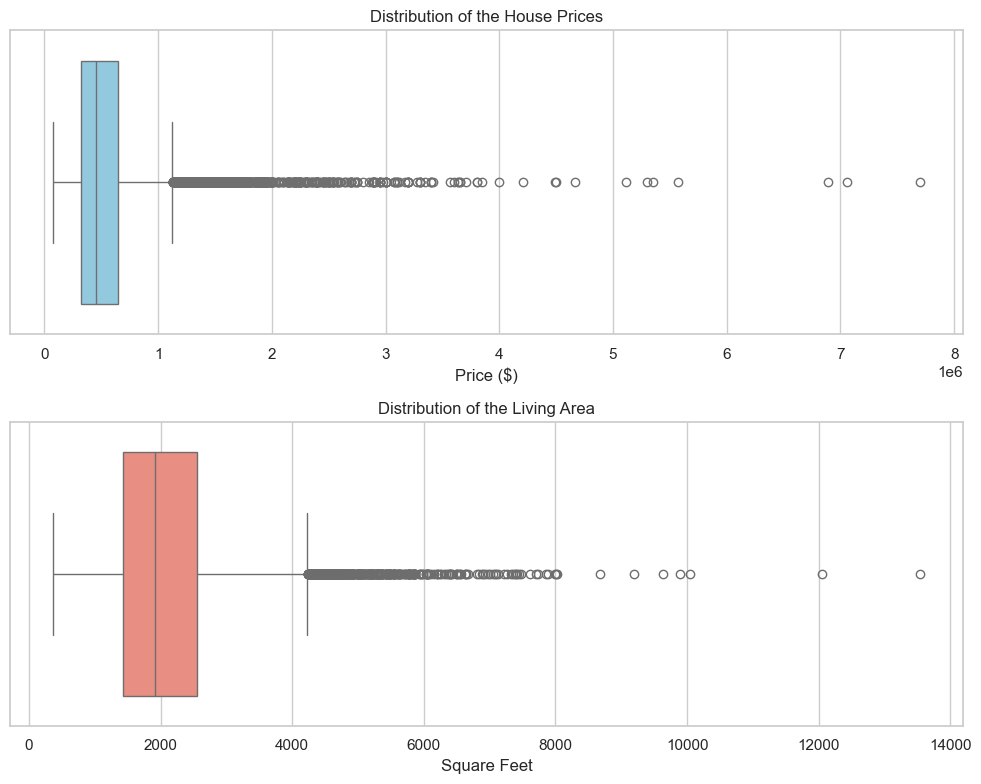

In [31]:
# Visualize the distribution of house-prices and sqft_living


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10, 8))

# Boxplot for House Price
sns.boxplot(x=house_details_sales['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of the House Prices')
axes[0].set_xlabel('Price ($)')

# Boxplot for Square Feet Living
sns.boxplot(x=house_details_sales['sqft_living'], ax=axes[1], color='salmon')
axes[1].set_title('Distribution of the Living Area')
axes[1].set_xlabel('Square Feet')

plt.tight_layout()
plt.show()

,Construction Decade,Total Sales,Trimmed Mean Purchase Price ($),Trimmed Mean Estimated Profit ($),Trimmed Mean Profit Margin (%)
0,1970s,2285,"$451,338.22","$20,846.41",5.09%
1,2000s,3515,"$533,589.58","$21,004.06",4.3%
2,1960s,2658,"$405,894.62","$14,626.36",3.85%
3,1910s,805,"$529,750.52","$7,601.86",2.87%
4,1900s,645,"$571,022.82","$7,771.86",2.71%
5,1990s,2232,"$516,925.06","$9,112.13",1.92%
6,1950s,2450,"$428,639.57","$1,479.63",0.94%
7,2010s,1241,"$571,318.07",$-381.96,-0.04%
8,1920s,1192,"$549,148.72","$-5,659.38",-0.11%
9,1940s,1763,"$403,414.32","$-5,088.61",-0.25%


C:\Users\damfe\AppData\Local\Temp\ipykernel_29072\2088478245.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


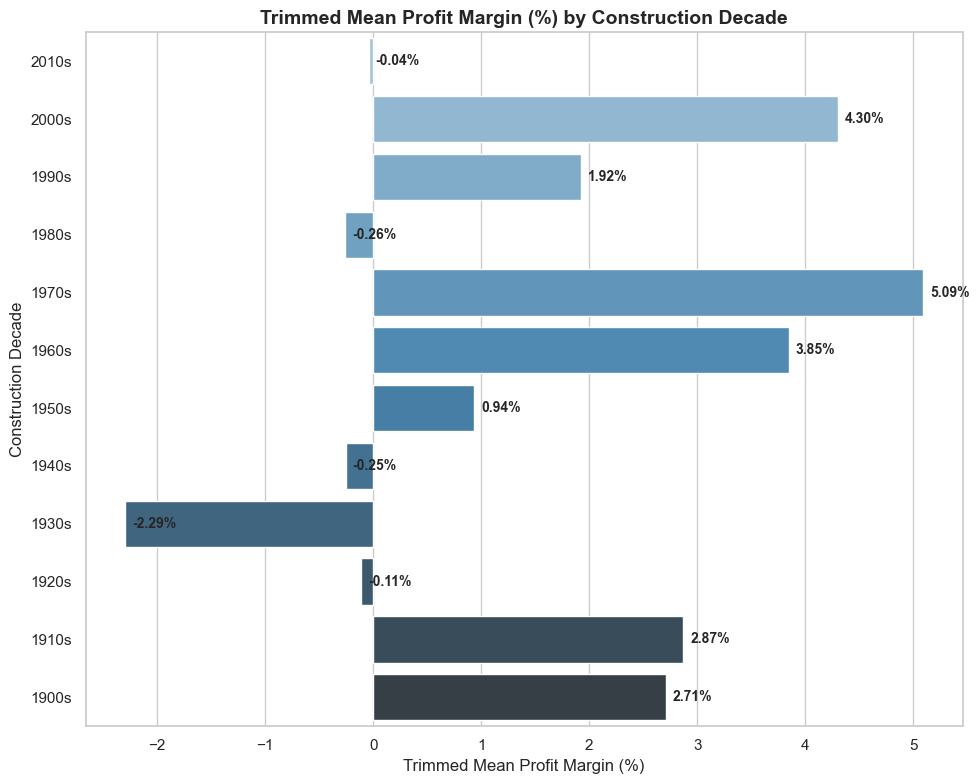

In [33]:
# 1. Find out the best Historical Houses by ROI 


df = house_details_sales.copy()

# Decades creation
df['sales_date'] = pd.to_datetime(df['sales_date'])
df['sale_year'] = df['sales_date'].dt.year
df['house_age_at_sale'] = df['sale_year'] - df['yr_built']

df['decade'] = (df['yr_built'] // 10) * 10
df['decade_str'] = df['decade'].astype(str) + 's'


df['price_per_sqft'] = df['price'] / df['sqft_living']

market_benchmark = df.groupby(['zipcode', 'grade']).agg(
    benchmark_price_per_sqft=('price_per_sqft', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# Merging to the main df
df_profit = df.merge(market_benchmark, on=['zipcode', 'grade'], how='left')

# Calculating estimated market value, estimated profit, and profit margin percentage
df_profit['estimated_market_value'] = df_profit['sqft_living'] * df_profit['benchmark_price_per_sqft']
df_profit['estimated_profit'] = df_profit['estimated_market_value'] - df_profit['price']
df_profit['profit_margin_pct'] = df_profit['estimated_profit'] / df_profit['price']

# Grouping by construction decades 
profit_by_decade = df_profit.groupby('decade_str').agg(
    total_sales=('price', 'count'),
    trimmed_purchase_price=('price', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_estimated_profit=('estimated_profit', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_profit_margin_pct=('profit_margin_pct', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# Just sorting and displaying the df as a table
top_decades = profit_by_decade.sort_values(by='avg_profit_margin_pct', ascending=False)

display_df = top_decades.copy()
display_df = display_df.rename(columns={
    'decade_str': 'Construction Decade',
    'total_sales': 'Total Sales',
    'trimmed_purchase_price': 'Trimmed Mean Purchase Price ($)',
    'avg_estimated_profit': 'Trimmed Mean Estimated Profit ($)',
    'avg_profit_margin_pct': 'Trimmed Mean Profit Margin (%)'
})

display_df['Trimmed Mean Profit Margin (%)'] = (display_df['Trimmed Mean Profit Margin (%)'] * 100).round(2).astype(str) + '%'
display_df['Trimmed Mean Purchase Price ($)'] = display_df['Trimmed Mean Purchase Price ($)'].apply(lambda x: f"${x:,.2f}")
display_df['Trimmed Mean Estimated Profit ($)'] = display_df['Trimmed Mean Estimated Profit ($)'].apply(lambda x: f"${x:,.2f}")

display_df = display_df.reset_index(drop=True)
display(display_df)



# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

plot_data = profit_by_decade.sort_values(by='decade_str', ascending=False)

ax = sns.barplot(
    data=plot_data, 
    y='decade_str', 
    x=plot_data['avg_profit_margin_pct'] * 100, 
    palette='Blues_d'
)

plt.title('Trimmed Mean Profit Margin (%) by Construction Decade', fontsize=14, fontweight='bold')
plt.xlabel('Trimmed Mean Profit Margin (%)', fontsize=12)
plt.ylabel('Construction Decade', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', 
                fontsize=10, fontweight='bold',
                xytext=(5, 0), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

,Renovation Status,Total Sales,Trimmed Mean Purchase Price ($),Trimmed Mean Estimated Profit ($),Trimmed Mean Profit Margin (%)
0,Not Renovated,20853,"$476,704.22","$8,558.36",2.21%
1,Renovated,744,"$666,779.76","$-13,222.16",-0.7%


C:\Users\damfe\AppData\Local\Temp\ipykernel_29072\2207360176.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


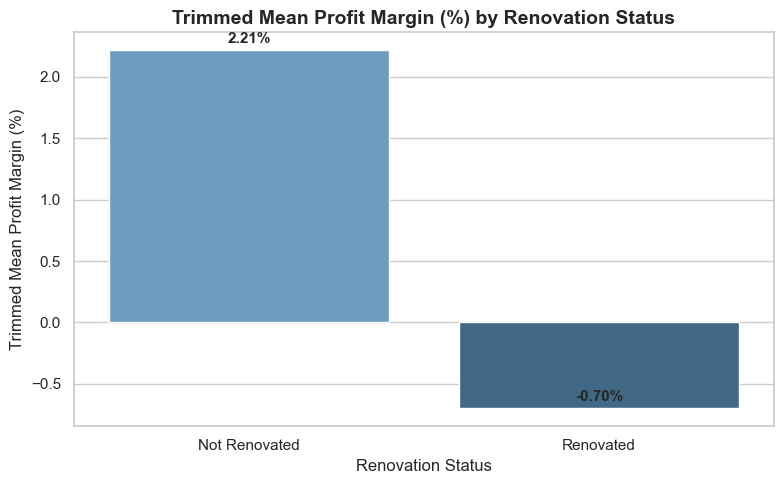

In [34]:
### 2 Comparing ROI for Renovated or Non Renovated Houses


df = house_details_sales.copy()

df['sales_date'] = pd.to_datetime(df['sales_date'])
df['sale_year'] = df['sales_date'].dt.year

df['renovation_status'] = df['yr_renovated'].apply(
    lambda x: 'Renovated' if pd.notnull(x) and x > 0 else 'Not Renovated'
)

df['price_per_sqft'] = df['price'] / df['sqft_living']

market_benchmark = df.groupby(['zipcode', 'grade']).agg(
    benchmark_price_per_sqft=('price_per_sqft', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# Merging nto the main df
df_profit = df.merge(market_benchmark, on=['zipcode', 'grade'], how='left')

# Calculating estimated market value, estimated profit, and profit margin percentage
df_profit['estimated_market_value'] = df_profit['sqft_living'] * df_profit['benchmark_price_per_sqft']
df_profit['estimated_profit'] = df_profit['estimated_market_value'] - df['price']
df_profit['profit_margin_pct'] = df_profit['estimated_profit'] / df['price']

# 7. Grouping by by renovation status
profit_by_renovation = df_profit.groupby('renovation_status').agg(
    total_sales=('price', 'count'),
    trimmed_purchase_price=('price', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_estimated_profit=('estimated_profit', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_profit_margin_pct=('profit_margin_pct', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# displaying the df as a table
display_df = profit_by_renovation.copy()
display_df = display_df.rename(columns={
    'renovation_status': 'Renovation Status',
    'total_sales': 'Total Sales',
    'trimmed_purchase_price': 'Trimmed Mean Purchase Price ($)',
    'avg_estimated_profit': 'Trimmed Mean Estimated Profit ($)',
    'avg_profit_margin_pct': 'Trimmed Mean Profit Margin (%)'
})

display_df['Trimmed Mean Profit Margin (%)'] = (display_df['Trimmed Mean Profit Margin (%)'] * 100).round(2).astype(str) + '%'
display_df['Trimmed Mean Purchase Price ($)'] = display_df['Trimmed Mean Purchase Price ($)'].apply(lambda x: f"${x:,.2f}")
display_df['Trimmed Mean Estimated Profit ($)'] = display_df['Trimmed Mean Estimated Profit ($)'].apply(lambda x: f"${x:,.2f}")

display_df = display_df.reset_index(drop=True)

display(display_df)

# Vizulalization

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=profit_by_renovation, 
    x='renovation_status', 
    y=profit_by_renovation['avg_profit_margin_pct'] * 100, 
    palette='Blues_d'
)

plt.title('Trimmed Mean Profit Margin (%) by Renovation Status', fontsize=14, fontweight='bold')
plt.ylabel('Trimmed Mean Profit Margin (%)', fontsize=12)
plt.xlabel('Renovation Status', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold',
                xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

,Sale Month,Total Sales,Trimmed Mean Purchase Price ($),Trimmed Mean Estimated Profit ($),Trimmed Mean Profit Margin (%)
0,Jan,978,"$463,808.50","$8,321.17",2.92%
1,Feb,1247,"$455,079.06",$795.31,0.6%
2,Mar,1875,"$485,501.41","$-8,141.38",-1.44%
3,Apr,2229,"$504,889.83","$-18,273.04",-3.34%
4,May,2414,"$489,057.07","$6,876.42",2.07%
5,Jun,2178,"$498,613.26","$12,093.20",2.76%
6,Jul,2211,"$490,482.15","$14,492.59",3.4%
7,Aug,1939,"$478,379.52","$15,992.94",3.73%
8,Sep,1771,"$474,915.82","$15,442.42",3.79%
9,Oct,1876,"$477,584.99","$19,256.77",4.55%


C:\Users\damfe\AppData\Local\Temp\ipykernel_29072\191961017.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


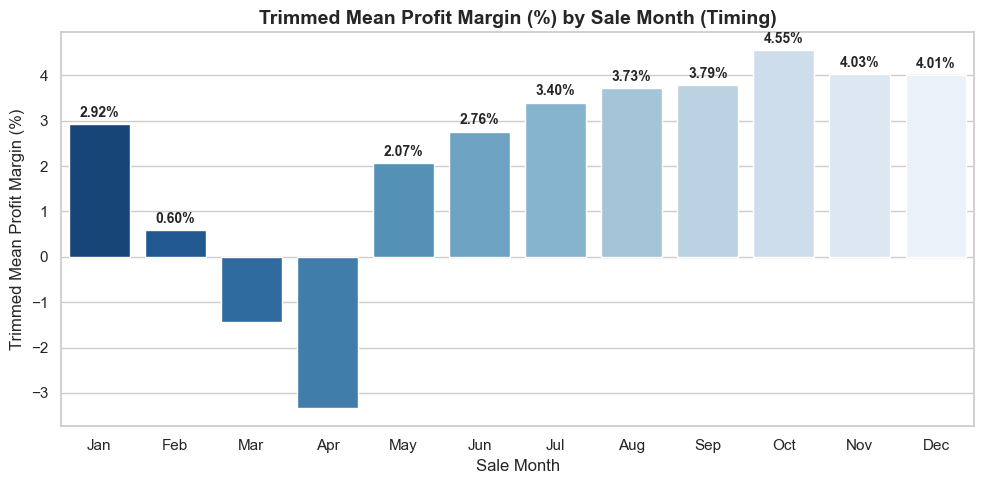

In [35]:
## 3. Best Profit-Margin by Month

df = house_details_sales.copy()


df['sales_date'] = pd.to_datetime(df['sales_date'])
df['sale_month'] = df['sales_date'].dt.month


df['price_per_sqft'] = df['price'] / df['sqft_living']

# Calculating benchmark 
market_benchmark = df.groupby(['zipcode', 'grade']).agg(
    benchmark_price_per_sqft=('price_per_sqft', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# Merging with the dataframe
df_profit = df.merge(market_benchmark, on=['zipcode', 'grade'], how='left')

# Calculating estimated_market value, estimated_profit, and profit_margin_percentage


df_profit['estimated_market_value'] = df_profit['sqft_living'] * df_profit['benchmark_price_per_sqft']
df_profit['estimated_profit'] = df_profit['estimated_market_value'] - df_profit['price']
df_profit['profit_margin_pct'] = df_profit['estimated_profit'] / df_profit['price']

# Grouping by sale month 
timing_by_month = df_profit.groupby('sale_month').agg(
    total_sales=('price', 'count'),
    trimmed_purchase_price=('price', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_estimated_profit=('estimated_profit', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_profit_margin_pct=('profit_margin_pct', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# Rename the month column

month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
timing_by_month['Month'] = timing_by_month['sale_month'].map(month_names)



## Display the data as a table

display_df = timing_by_month.copy()
display_df = display_df[['Month', 'total_sales', 'trimmed_purchase_price', 'avg_estimated_profit', 'avg_profit_margin_pct']]
display_df = display_df.rename(columns={
    'Month': 'Sale Month',
    'total_sales': 'Total Sales',
    'trimmed_purchase_price': 'Trimmed Mean Purchase Price ($)',
    'avg_estimated_profit': 'Trimmed Mean Estimated Profit ($)',
    'avg_profit_margin_pct': 'Trimmed Mean Profit Margin (%)'
})

display_df['Trimmed Mean Profit Margin (%)'] = (display_df['Trimmed Mean Profit Margin (%)'] * 100).round(2).astype(str) + '%'
display_df['Trimmed Mean Purchase Price ($)'] = display_df['Trimmed Mean Purchase Price ($)'].apply(lambda x: f"${x:,.2f}")
display_df['Trimmed Mean Estimated Profit ($)'] = display_df['Trimmed Mean Estimated Profit ($)'].apply(lambda x: f"${x:,.2f}")

display_df = display_df.reset_index(drop=True)

# Visulization

display(display_df)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=timing_by_month,
    x='Month',
    y=timing_by_month['avg_profit_margin_pct'] * 100,
    order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    palette='Blues_r'
)

plt.title('Trimmed Mean Profit Margin (%) by Sale Month (Timing)', fontsize=14, fontweight='bold')
plt.ylabel('Trimmed Mean Profit Margin (%)', fontsize=12)
plt.xlabel('Sale Month', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [37]:
### 4.1 Grouping Zipcodes in Regions with Prompting LLM (Gemini)
## You need your own Gemini API Key in .env file, in order to run this cell


load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    raise ValueError("API key not found. Make sure to configure the .env file with GEMINI_API_KEY.")

client = genai.Client(api_key=api_key)


df = house_details_sales.copy()

# Extracting a clean zipcode list for the LLM

unique_zipcodes = df['zipcode'].astype(str).unique().tolist()

# Prompt to call Gemini and organize Zipcodes by Specifics Regions

prompt = f"""
You are a real estate expert in King County, Washington. 
I have a list of zip codes. For each zip code, classify it into one of these broad macro-regions: 
- "Seattle North"
- "Seattle Central"
- "Seattle South"
- "Eastside (Bellevue/Redmond)"
- "South County"
- "North & Rural County"

Return your response strictly as a Python dictionary where the key is the string of the zip code and the value is the macro-region name. Do not include markdown formatting like ```python, just output the raw dictionary.

Zip codes list: {unique_zipcodes}
"""

response = client.models.generate_content(
    model='gemini-3.5-flash',
    contents=prompt,
)


# Formatting the response and filtering every Zipcode by regions 

cleaned_response = re.sub(r'```python|```', '', response.text).strip()
zip_to_neighborhood = ast.literal_eval(cleaned_response)

df['zipcode_str'] = df['zipcode'].astype(str)
df['neighborhood'] = df['zipcode_str'].map(zip_to_neighborhood).fillna('Other Region')

# Display the head of the final table
display(df[['id_house', 'sales_date', 'price', 'zipcode', 'neighborhood']].head(20))

,id_house,sales_date,price,zipcode,neighborhood
0,7129300520,2014-10-13,221900.0,98178,Seattle South
1,6414100192,2014-12-09,538000.0,98125,Seattle North
2,5631500400,2015-02-25,180000.0,98028,North & Rural County
3,2487200875,2014-12-09,604000.0,98136,Seattle South
4,1954400510,2015-02-18,510000.0,98074,Eastside (Bellevue/Redmond)
5,7237550310,2014-05-12,1230000.0,98053,Eastside (Bellevue/Redmond)
6,1321400060,2014-06-27,257500.0,98003,South County
7,2008000270,2015-01-15,291850.0,98198,South County
8,2414600126,2015-04-15,229500.0,98146,Seattle South
9,3793500160,2015-03-12,323000.0,98038,South County


,Macro-Region,Total Sales,Trimmed Mean Purchase Price ($),Trimmed Mean Estimated Profit ($),Trimmed Mean Profit Margin (%)
0,Seattle South,2868,"$406,920.77","$10,601.07",6.15%
1,Seattle North,3836,"$513,427.80","$11,467.06",4.28%
2,Seattle Central,1273,"$761,138.84","$14,657.56",2.94%
3,Eastside (Bellevue/Redmond),5697,"$676,641.82","$11,011.48",2.56%
4,South County,6073,"$311,891.10","$4,175.31",2.31%
5,North & Rural County,1850,"$435,631.08","$6,021.47",2.23%


C:\Users\damfe\AppData\Local\Temp\ipykernel_29072\825967890.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


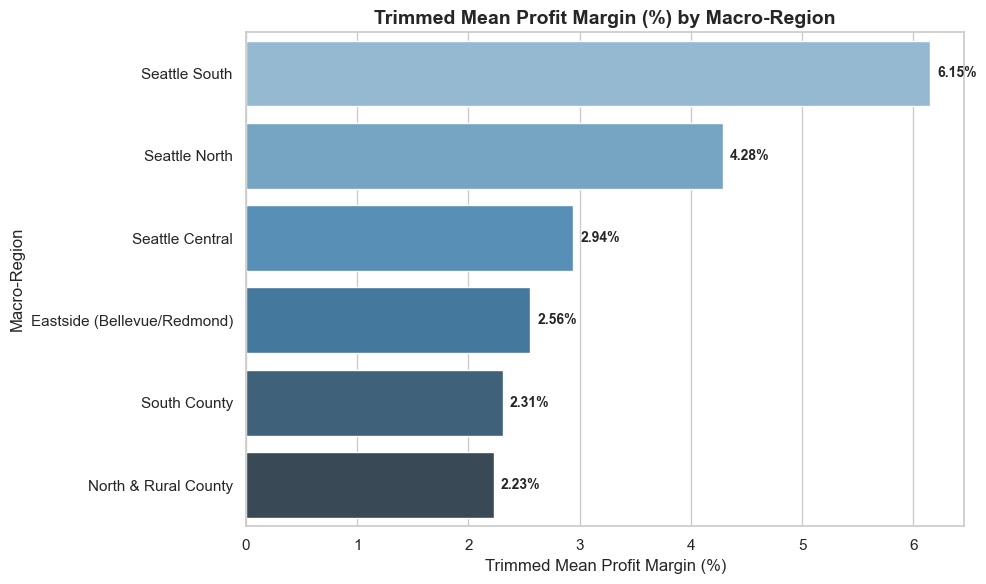

In [38]:

# 4.2 Calculating profit-margin by Regions

df['price_per_sqft'] = df['price'] / df['sqft_living']

# Calculating benchmark
market_benchmark = df.groupby(['neighborhood', 'grade']).agg(
    benchmark_price_per_sqft=('price_per_sqft', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()

# Merging into the df 
df_profit = df.merge(market_benchmark, on=['neighborhood', 'grade'], how='left')

# Calculating estimated market value and profit margin
df_profit['estimated_market_value'] = df_profit['sqft_living'] * df_profit['benchmark_price_per_sqft']
df_profit['estimated_profit'] = df_profit['estimated_market_value'] - df['price']
df_profit['profit_margin_pct'] = df_profit['estimated_profit'] / df['price']

# Grouping by regions
profit_by_neighborhood = df_profit.groupby('neighborhood').agg(
    total_sales=('price', 'count'),
    trimmed_purchase_price=('price', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_estimated_profit=('estimated_profit', lambda x: trim_mean(x, proportiontocut=0.10)),
    avg_profit_margin_pct=('profit_margin_pct', lambda x: trim_mean(x, proportiontocut=0.10))
).reset_index()


top_neighborhoods = profit_by_neighborhood.sort_values(
    by='avg_profit_margin_pct', ascending=False
).head(10)

# Display the df as a table
display_df = top_neighborhoods.copy()
display_df = display_df.rename(columns={
    'neighborhood': 'Macro-Region',
    'total_sales': 'Total Sales',
    'trimmed_purchase_price': 'Trimmed Mean Purchase Price ($)',
    'avg_estimated_profit': 'Trimmed Mean Estimated Profit ($)',
    'avg_profit_margin_pct': 'Trimmed Mean Profit Margin (%)'
})

display_df['Trimmed Mean Profit Margin (%)'] = (display_df['Trimmed Mean Profit Margin (%)'] * 100).round(2).astype(str) + '%'
display_df['Trimmed Mean Purchase Price ($)'] = display_df['Trimmed Mean Purchase Price ($)'].apply(lambda x: f"${x:,.2f}")
display_df['Trimmed Mean Estimated Profit ($)'] = display_df['Trimmed Mean Estimated Profit ($)'].apply(lambda x: f"${x:,.2f}")

display_df = display_df.reset_index(drop=True)


display(display_df)


# Visulization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


plot_data = top_neighborhoods.sort_values(by='avg_profit_margin_pct', ascending=False)

ax = sns.barplot(
    data=plot_data,
    y='neighborhood',
    x=plot_data['avg_profit_margin_pct'] * 100,
    palette='Blues_d'
)

plt.title('Trimmed Mean Profit Margin (%) by Macro-Region', fontsize=14, fontweight='bold')
plt.xlabel('Trimmed Mean Profit Margin (%)', fontsize=12)
plt.ylabel('Macro-Region', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', 
                fontsize=10, fontweight='bold',
                xytext=(5, 0), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Final Conclusions

Based on the profit-margin metric I created, I found that homes built in the 1970s, without significant renovations, purchased in the month of October, and located in the South Seattle area, generally offered the best Return on Investment (ROI).

However, it's important to understand that, as always, historical data doesn't guarantee the future in any way, and the market, due to multiple variables impossible to control, is always volatile and dynamic.

On the other hand, it's important to note that although I tried to smooth the effect of outliers on the price by using a median trimmed to 10%, in my opinion, this isn't enough. This is more of a conservative decision that allowed me to maintain a significant volume of data to draw conclusions, but the data is still clearly heavily influenced by the presence of outliers. [ Review the chart below for more details ]

For a subsequent phase of improvement, it would be interesting to apply a more robust analysis and treatment of outliers to mitigate their influence.

#### Some of the methods for handling outliers in the future in that repository will be:

### Log-Transformation for Skewed Features.
### Multivariate Outlier Detection.

I will continue to update with the next developments.


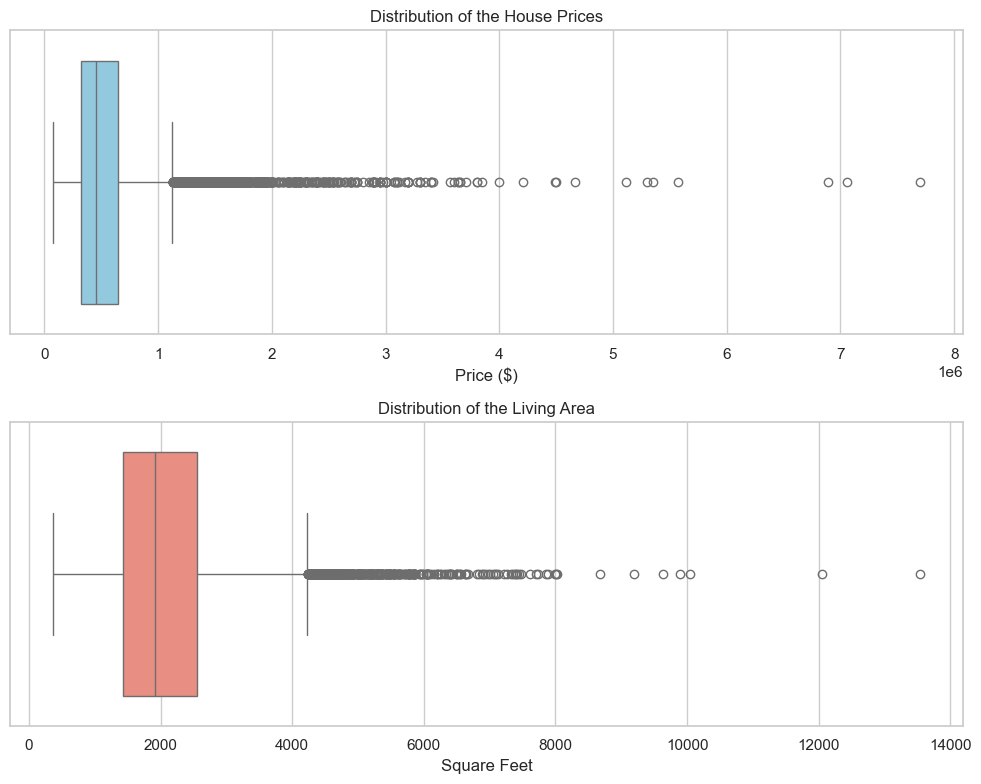

In [42]:
## Data Distribution of house prices and sqft

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10, 8))

# Boxplot for House Price
sns.boxplot(x=house_details_sales['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of the House Prices')
axes[0].set_xlabel('Price ($)')

# Boxplot for Square Feet Living
sns.boxplot(x=house_details_sales['sqft_living'], ax=axes[1], color='salmon')
axes[1].set_title('Distribution of the Living Area')
axes[1].set_xlabel('Square Feet')

plt.tight_layout()
plt.show()

In [43]:
# 1. To Export Tables I am using
house_details.to_csv('data/king_county_house_details.csv', index=False)
house_sales.to_csv('data/king_county_house_sales.csv', index=False)
house_details_sales.to_csv('data/king_county_house_details_sales.csv', index=False)